## Setup

In [99]:
import numpy as np
import warp as wp
import h5py
from tqdm import tqdm

wp.config.verbose = True
wp.config.print_launches = True
wp.config.verbose_warnings = True

# Explicitly initializing Warp is not necessary but
# we do it here to ensure everything is good to go.
wp.init()

if not wp.get_cuda_device_count():
    print(
        "In this notebook I assume the presence of "
        "a CUDA-compatible device, the code will run very slowly or not at all if it's not available."
    )

## Config

In [100]:
BALL_RADIUS = 0.075057  # meters (6 inches)
BALL_CROSS_SECTIONAL_AREA = np.pi * BALL_RADIUS ** 2  # m^2
BALL_MASS = 0.21499   # kg
GRAVITY_ACCELERATION = 9.81
HOOP_HEIGHT_Z = 1.3288 # meters (52 inches)
EFFECTIVE_RADIUS = 0.44748 # meters (17.625 inches) - This is the distance from the center of the hoop to the point where the ball would just clear the rim, accounting for the ball's radius.
AIR_DENSITY = 1.225  # kg/m^3
DRAG_COEFFICIENT = 0.47  # Typical for a sphere

MAGNUS_COEFFICIENT = 0.2  # Placeholder value for Magnus effect TODO: This will need to be tuned based on real-world testing to match observed ball behavior.


# Base Lookup Arrays
EXIT_VELOCITY_VALUES = np.arange(6.0, 20 + 0.15, 0.15, dtype=np.float32)
HOOD_ANGLE_VALUES = np.radians(np.arange(20.0, 80.1, 2, dtype=np.uint8))
TURRET_ANGLE_VALUES = np.radians(np.arange(-150.0, 150.1, 4, dtype=np.int16))
DISTANCE_VALUES = np.arange(1.0, 7.1, 0.15, dtype=np.float32)
ROBOT_VELOCITY_VALUES = np.arange(0.0, 4.1, 0.4, dtype=np.float32)
ROBOT_HEADING_ANGLE_VALUES = np.radians(np.arange(-180.0, 180, 5, dtype=np.float32))

TOTAL_SHOTS = (
    len(EXIT_VELOCITY_VALUES) * 
    len(HOOD_ANGLE_VALUES) * 
    len(TURRET_ANGLE_VALUES) * 
    len(DISTANCE_VALUES) * 
    len(ROBOT_VELOCITY_VALUES) * 
    len(ROBOT_HEADING_ANGLE_VALUES)
)

print("Total Shots:", TOTAL_SHOTS)

Total Shots: 7267883040


In [101]:
# Dataset Column Definitions for HDF5 Output
DATASET_COLUMNS = [
    'exit_velocity', 'hood_angle', 'turret_angle', 'distance_to_target', 'robot_velocity', 'robot_heading_angle', 
    'time_of_flight', 'crossing_x_coordinate', 'crossing_y_coordinate', 'distance_from_center', 'edge_clearance', 
    'entry_speed', 'entry_velocity_x', 'entry_velocity_y', 'entry_velocity_z', 'entry_angle'
]

## Physics

The physics formula for air drag is:

![physics formula for air drag](media/air_drag_force.png)

Cd is the `drag_constant`

The physics formula for Magnus force caused by ball backspin is:

![formula for Magnus force](media/magnus_force.png)

CL is the `magnus_constant`

The direction is perpendicular to the direction of the velocity vector, and the rotation vector

In [102]:
@wp.func
def compute_acceleration(velocity: wp.vec3, drag_constant: float, magnus_constant: float) -> wp.vec3:
    velocity_magnitude = wp.length(velocity)
    acceleration_drag = wp.float32(-1/2) * wp.float32(AIR_DENSITY) * wp.float32(BALL_CROSS_SECTIONAL_AREA) * wp.float32(drag_constant) * velocity_magnitude * velocity / wp.float32(BALL_MASS)
    acceleration_gravity = wp.vec3(0.0, 0.0, -9.81)

    # Magnus effect (backspin): force ∝ cross(omega, v). Use a horizontal rotation axis for backspin.
    rotation_axis = wp.vec3(0.0, 1.0, 0.0)  # axis of rotation for backspin
    # Encode spin magnitude into magnus_constant; scale with |v| and use cross product for direction
    acceleration_magnus = wp.float32(0.5) * wp.float32(AIR_DENSITY) * wp.float32(BALL_CROSS_SECTIONAL_AREA) * wp.float32(magnus_constant) * velocity_magnitude * wp.cross(rotation_axis, velocity) / wp.float32(BALL_MASS)
    
    return acceleration_drag + acceleration_gravity + acceleration_magnus

### Verify calculation with simple visualization

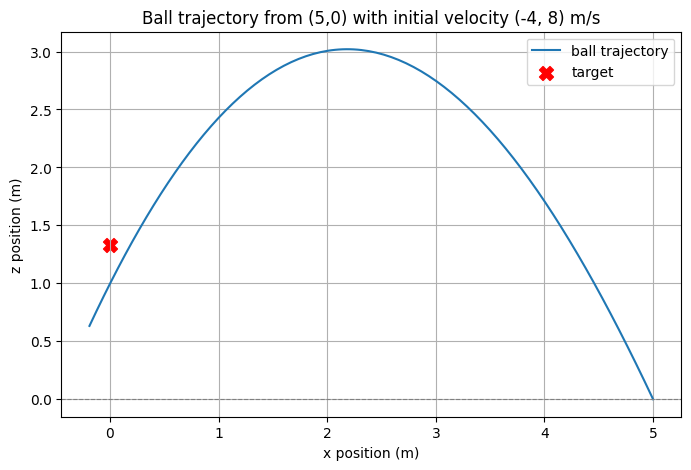

In [103]:
from matplotlib import pyplot as plt

pos = np.array([5.0, 0.0, 0.0], dtype=np.float32)
vel = wp.vec3(-4.0, 0.0, 8.0)

xs = []
zs = []

dt = 0.01
max_steps = 150

for _ in range(max_steps):
    xs.append(pos[0])
    zs.append(pos[2])

    accel = compute_acceleration(vel, DRAG_COEFFICIENT, MAGNUS_COEFFICIENT)
    accel_np = np.array([accel.x, accel.y, accel.z], dtype=np.float32)

    vel = wp.vec3(vel.x + accel_np[0] * dt,
                  vel.y + accel_np[1] * dt,
                  vel.z + accel_np[2] * dt)

    pos += np.array([vel.x, vel.y, vel.z], dtype=np.float32) * dt

    if pos[2] <= 0.0 and len(zs) > 1:
        break

plt.figure(figsize=(8, 5))
plt.plot(xs, zs, label="ball trajectory")
plt.scatter([0.0], [HOOP_HEIGHT_Z], color="red", marker="X", s=100, label="target")
plt.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("x position (m)")
plt.ylabel("z position (m)")
plt.title("Ball trajectory from (5,0) with initial velocity (-4, 8) m/s")
plt.legend()
plt.grid(True)
plt.gca()
plt.show()

### Indexing
Each GPU thread has a unique index, given by wp.tid(), we need to turn that index into 6 different indexes to make sure each thread processes a unique shot with unique starting parameters

In [104]:
@wp.func
def decode_shot_indices(
    linear_index: wp.int32,
    dimension_robot_heading_angle: wp.int32,
    dimension_robot_velocity: wp.int32,
    dimension_distance: wp.int32,
    dimension_turret_angle: wp.int32,
    dimension_hood_angle: wp.int32,
    dimension_exit_velocity: wp.int32
) -> tuple[
    wp.int32,
    wp.int32,
    wp.int32,
    wp.int32,
    wp.int32,
    wp.int32
]:
    """
    Decode a flattened global index into the six shot parameter indices.

    The decoded order corresponds to the nesting:
        exit_velocity -> hood_angle -> turret_angle -> distance ->
        robot_velocity -> robot_heading_angle

    robot_heading_angle is the fastest-varying dimension, so it is decoded first.
    """
    index_robot_heading_angle = linear_index % dimension_robot_heading_angle
    linear_index = linear_index // dimension_robot_heading_angle

    index_robot_velocity = linear_index % dimension_robot_velocity
    linear_index = linear_index // dimension_robot_velocity

    index_distance = linear_index % dimension_distance
    linear_index = linear_index // dimension_distance

    index_turret_angle = linear_index % dimension_turret_angle
    linear_index = linear_index // dimension_turret_angle

    index_hood_angle = linear_index % dimension_hood_angle
    linear_index = linear_index // dimension_hood_angle

    index_exit_velocity = linear_index % dimension_exit_velocity

    return (
        index_robot_heading_angle,
        index_robot_velocity,
        index_distance,
        index_turret_angle,
        index_hood_angle,
        index_exit_velocity,
    )

### Kernel

In [105]:
@wp.kernel
def simulate_shots(
    # 1D Lookup arrays
    exit_velocity_values: wp.array(dtype=wp.float32), # type: ignore
    hood_angle_values: wp.array(dtype=wp.float32), # type: ignore
    turret_angle_values: wp.array(dtype=wp.float32), # type: ignore
    distance_values: wp.array(dtype=wp.float32), # type: ignore
    robot_velocity_values: wp.array(dtype=wp.float32), # type: ignore
    robot_heading_angle_values: wp.array(dtype=wp.float32), # type: ignore
    
    # Dimensions for index decoding
    dimension_robot_heading_angle: wp.int32, 
    dimension_robot_velocity: wp.int32, 
    dimension_distance: wp.int32, 
    dimension_turret_angle: wp.int32, 
    dimension_hood_angle: wp.int32, 
    dimension_exit_velocity: wp.int32,
    global_offset: wp.int32,
    
    # Physics Parameters
    drag_constant: wp.float32,
    magnus_constant: wp.float32,
    hoop_height_z: wp.float32, 
    effective_radius: wp.float32, 
    time_step: wp.float32, 
    maximum_steps: wp.int32,
    
    # Outputs 
    results: wp.array(dtype=wp.float32, ndim=2), # type: ignore
    counter: wp.array(dtype=wp.int32) # type: ignore
):
    # Map 1D global index back to 6D state coordinates
    index = global_offset + wp.tid()

    (
        index_robot_heading_angle,
        index_robot_velocity,
        index_distance,
        index_turret_angle,
        index_hood_angle,
        index_exit_velocity
    ) = decode_shot_indices(index, dimension_robot_heading_angle, dimension_robot_velocity, dimension_distance, dimension_turret_angle, dimension_hood_angle, dimension_exit_velocity)

    exit_velocity = exit_velocity_values[index_exit_velocity]
    hood_angle = hood_angle_values[index_hood_angle]
    turret_angle = turret_angle_values[index_turret_angle]
    distance_to_target = distance_values[index_distance]
    robot_velocity = robot_velocity_values[index_robot_velocity]
    robot_heading_angle = robot_heading_angle_values[index_robot_heading_angle]

    # Initialize shot origin
    position = wp.vec3(distance_to_target, 0.0, 0.0)

    # Robot base velocity 
    # When the heading is 0 (facing directly towards the target), the velocity should be (-robot_velocity, 0).
    velocity_robot_x = -robot_velocity * wp.cos(robot_heading_angle)
    velocity_robot_y = robot_velocity * wp.sin(robot_heading_angle)

    # Initial velocity of the ball relative to the robot (in robot's local frame)
    velocity_ball_robot_x = -exit_velocity * wp.cos(turret_angle)
    velocity_ball_robot_y = exit_velocity * wp.sin(turret_angle)
    velocity_ball_robot_z = exit_velocity * wp.sin(hood_angle)

    # Total initial velocity of the ball in world frame
    velocity = wp.vec3(velocity_robot_x + velocity_ball_robot_x,
                       velocity_robot_y + velocity_ball_robot_y,
                       velocity_ball_robot_z
    )

    current_time = wp.float32(0.0)
    previous_position = position
    previous_velocity = velocity

    # Run the simulation loop until the ball hits the ground or we reach maximum steps
    # RK4 integration for better accuracy
    for step in range(maximum_steps):
        # Check if the ball is below the target plane and moving downwards, if so we can stop the simulation early
        if position.z <= hoop_height_z and velocity.z < 0.0 and step > 0:
            break

        if position.z <= 0.0 and velocity.z < 0.0 and step > 0:
            break

        previous_position = position
        previous_velocity = velocity

        acceleration = compute_acceleration(velocity, drag_constant, magnus_constant)

        # RK4 Integration
        k1_vel = acceleration
        k1_pos = velocity

        k2_vel = compute_acceleration(velocity + 0.5 * time_step * k1_vel, drag_constant, magnus_constant)
        k2_pos = velocity + 0.5 * time_step * k1_vel

        k3_vel = compute_acceleration(velocity + 0.5 * time_step * k2_vel, drag_constant, magnus_constant)
        k3_pos = velocity + 0.5 * time_step * k2_vel

        k4_vel = compute_acceleration(velocity + time_step * k3_vel, drag_constant, magnus_constant)
        k4_pos = velocity + time_step * k3_vel

        velocity += (time_step / 6.0) * (k1_vel + 2.0*k2_vel + 2.0*k3_vel + k4_vel)
        position += (time_step / 6.0) * (k1_pos + 2.0*k2_pos + 2.0*k3_pos + k4_pos)

        current_time += time_step

        # Check for crossing the hoop plane (z >= hoop_height_z)
        if previous_position.z >= hoop_height_z and position.z <= hoop_height_z and previous_position.z != position.z:
            # Linear interpolation to find exact crossing point
            t_cross = (hoop_height_z - previous_position.z) / (position.z - previous_position.z)
            crossing_x = previous_position.x + t_cross * (position.x - previous_position.x)
            crossing_y = previous_position.y + t_cross * (position.y - previous_position.y)

            distance_from_center = wp.sqrt(crossing_x**2.0 + crossing_y**2.0)
            edge_clearance = effective_radius - distance_from_center

            # Is the ball inside the effective hoop radius?
            # Store results in the output array
            if edge_clearance >= 0.0:
                interpolated_velocity = previous_velocity + t_cross * (velocity - previous_velocity)
                entry_speed = wp.length(interpolated_velocity)
                
                if entry_speed > 0.0:
                    entry_angle = wp.acos(wp.abs(interpolated_velocity[2]) / entry_speed) * (180.0 / wp.pi)
                else:
                    entry_angle = 0.0

                shot_index = wp.atomic_add(counter, 0, 1)  # Get the next available index atomically
                if shot_index < results.shape[0]:  # Ensure we don't write out of bounds
                    results[shot_index, 0] = exit_velocity
                    results[shot_index, 1] = hood_angle * (180.0 / wp.pi)
                    results[shot_index, 2] = turret_angle * (180.0 / wp.pi)
                    results[shot_index, 3] = distance_to_target
                    results[shot_index, 4] = robot_velocity
                    results[shot_index, 5] = robot_heading_angle * (180.0 / wp.pi)
                    results[shot_index, 6] = crossing_x
                    results[shot_index, 7] = crossing_y
                    results[shot_index, 8] = distance_from_center
                    results[shot_index, 9] = edge_clearance
                    results[shot_index, 10] = entry_speed
                    results[shot_index, 11] = interpolated_velocity.x
                    results[shot_index, 12] = interpolated_velocity.y
                    results[shot_index, 13] = interpolated_velocity.z
                    results[shot_index, 14] = entry_angle


## Generator

In [106]:
batch_size = 10_000_000
num_batches = int(np.ceil(TOTAL_SHOTS / batch_size))

num_batches

727

In [107]:
exit_velocity_values_wp = wp.array(EXIT_VELOCITY_VALUES, dtype=wp.float32)
hood_angle_values_wp = wp.array(HOOD_ANGLE_VALUES, dtype=wp.float32)
turret_angle_values_wp = wp.array(TURRET_ANGLE_VALUES, dtype=wp.float32)
distance_values_wp = wp.array(DISTANCE_VALUES, dtype=wp.float32)
robot_velocity_values_wp = wp.array(ROBOT_VELOCITY_VALUES, dtype=wp.float32)
robot_heading_angle_values_wp = wp.array(ROBOT_HEADING_ANGLE_VALUES, dtype=wp.float32)

In [108]:
maximum_valid_per_batch = int(batch_size * 0.20)  # Use only 20% of the batch size to ensure we don't exceed output array bounds due to early stopping

results = wp.array(shape=(maximum_valid_per_batch, len(DATASET_COLUMNS)), dtype=wp.float32)
device_counter = wp.zeros(shape=(1,), dtype=wp.int32)

In [ ]:
output_file_name = "frc_shots_dataset.h5"

with h5py.File(output_file_name, "w") as h5file:
    dataset = h5file.create_dataset("valid_shots", shape=(0, len(DATASET_COLUMNS)), dtype='float32', maxshape=(None, len(DATASET_COLUMNS)), compression="lzf")

    dataset.attrs['columns'] = DATASET_COLUMNS

    total_valid_shots = 0

    global_offset = 0
    for batch in tqdm(range(num_batches), desc="Processing Batches"):
        global_offset = batch * batch_size
        current_dimension = min(batch_size, TOTAL_SHOTS - global_offset)  # Handle last batch which may be smaller

        device_counter.zero_()  # Reset device counter for this batch

        wp.launch(
            kernel=simulate_shots,
            dim=current_dimension,
            inputs=[
                exit_velocity_values_wp,
                hood_angle_values_wp,
                turret_angle_values_wp,
                distance_values_wp,
                robot_velocity_values_wp,
                robot_heading_angle_values_wp,
                wp.int32(len(ROBOT_HEADING_ANGLE_VALUES)),
                wp.int32(len(ROBOT_VELOCITY_VALUES)),
                wp.int32(len(DISTANCE_VALUES)),
                wp.int32(len(TURRET_ANGLE_VALUES)),
                wp.int32(len(HOOD_ANGLE_VALUES)),
                wp.int32(len(EXIT_VELOCITY_VALUES)),
                wp.int32(global_offset),
                wp.float32(DRAG_COEFFICIENT),
                wp.float32(MAGNUS_COEFFICIENT),
                wp.float32(HOOP_HEIGHT_Z),
                wp.float32(EFFECTIVE_RADIUS),
                wp.float32(0.005),  # time_step
                wp.int32(600),  # maximum_steps
                results,
                device_counter
            ],
        )

        wp.synchronize()  # Ensure the kernel has finished executing before reading results
        valid_count = int(device_counter.numpy()[0])

        if valid_count > 0:
            dataset.resize(total_valid_shots + valid_count, axis=0)
            dataset[total_valid_shots : total_valid_shots + valid_count] = results.numpy()[:valid_count]
            total_valid_shots += valid_count

        print(f"\nSimulation Complete. Generated {total_valid_shots:,} valid scoring configurations.")
        print(f"Dataset saved to: {output_file_name}")

In [111]:
with h5py.File("frc_shots_dataset.h5", "r") as f:
    def print_name(name):
        print(name)

    f.visit(print_name)

valid_shots


In [ ]:
import pandas
import h5py

def load_valid_shots_to_dataframe(file_path: str = "frc_shots_dataset.h5") -> pandas.DataFrame:
    """Reads the valid shots from HDF5 and converts them to a Pandas DataFrame."""
    with h5py.File(file_path, 'r') as hdf5_file:
        # Access the dataset that contains our computed quality scores
        dataset = hdf5_file['valid_shots']
        
        # Read the stored column names and decode them if they were saved as bytes
        column_headers = [
            header.decode('utf-8') if isinstance(header, bytes) else header 
            for header in dataset.attrs['columns']
        ]
        
        # Load the raw numerical array straight into memory as a DataFrame
        data_frame = pandas.DataFrame(dataset[:], columns=column_headers)
        
    return data_frame


# Load the data
shots_data_frame = load_valid_shots_to_dataframe()

# Quick sanity check: Display the shape and the top 5 highest-scoring shots
print(f"Loaded DataFrame with Shape: {shots_data_frame.shape}")
print("\n--- Top 5 Best Scoring Configurations ---")

shots_data_frame.sort_values(by=['hood_angle'], inplace=True)
shots_data_frame

Loaded DataFrame with Shape: (2728384, 16)

--- Top 5 Best Scoring Configurations ---


,exit_velocity,hood_angle,turret_angle,distance_to_target,robot_velocity,robot_heading_angle,time_of_flight,crossing_x_coordinate,crossing_y_coordinate,distance_from_center,edge_clearance,entry_speed,entry_velocity_x,entry_velocity_y,entry_velocity_z,entry_angle
1311727,6.0,58.023163,-49.999996,2.35,4.0,84.999992,-0.139765,-0.366807,0.392533,0.054947,4.229837,-4.131400,-0.611488,-0.670178,80.883598,0.0
1324616,6.0,59.981514,-49.999996,2.35,4.0,90.000000,-0.177709,-0.396593,0.434588,0.012892,4.018544,-3.784960,-0.596267,-1.211298,72.456665,0.0
1324617,6.0,59.981514,-49.999996,2.65,4.0,90.000000,0.122291,-0.396593,0.415020,0.032460,4.018544,-3.784960,-0.596267,-1.211298,72.456665,0.0
1324618,6.0,59.981514,-49.999996,2.65,4.0,84.999992,-0.129731,-0.409969,0.430005,0.017475,4.356326,-4.130073,-0.611488,-1.243445,73.415176,0.0
1324619,6.0,59.981514,-49.999996,2.80,4.0,84.999992,0.020270,-0.409969,0.410470,0.037010,4.356326,-4.130073,-0.611488,-1.243445,73.415176,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38602,6.0,61.995819,49.999996,2.80,4.0,-90.000000,0.082414,0.426789,0.434674,0.012806,4.149914,-3.783606,0.596267,-1.597054,67.366173,0.0
1336003,6.0,59.981514,49.999996,2.65,4.0,-84.999992,-0.129731,0.409969,0.430005,0.017475,4.356326,-4.130073,0.611488,-1.243445,73.415176,0.0
1336004,6.0,59.981514,49.999996,2.95,4.0,-84.999992,0.170270,0.409969,0.443922,0.003558,4.356326,-4.130073,0.611488,-1.243445,73.415176,0.0
1336000,6.0,59.981514,49.999996,2.35,4.0,-90.000000,-0.177709,0.396593,0.434588,0.012892,4.018544,-3.784960,0.596267,-1.211298,72.456665,0.0
